In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv("../Data/horror_movies.csv")

df.drop(['adult', 'collection', 'poster_path','backdrop_path'], axis=1, inplace=True)
df.dropna(subset=['overview'], inplace=True)
df['release_date'] = pd.to_datetime(df['release_date'])
df_released = df.drop(df[df['status'] != 'Released'].index).reset_index(drop=True)
movie_df = df_released


In [3]:
#MY TOP 5 HORROR MOVIES
#midsommar, as above so below, get out, nope, rosemary's baby, paranormal activity the marked ones, 
# les affames(ravenous), tremors, anacoda, the cabin in the woods, werewolves within, 28 days later
# it's what's inside, skeleton key, infinity pool, shaun of the dead, ernest scared stupid, 
# pearl, critters, puppet master 

#NOT INCLUDED IN DATASET:
#sinners( this is one of the best movies ever made and that needs to be said)
#terrifier 3 (horrifying and deeply disturbing, but for the girls )
#28 years later the bone temple (i laughed, i cried, i wanted an alpha zombie best friend)

df1 = movie_df[movie_df['title'] == 'Midsommar'].copy()
df2 = movie_df[movie_df['title'] == 'Werewolves Within'].copy()
df3 = movie_df[movie_df['title'] == 'Tremors'].copy()
df4 = movie_df[movie_df['title'] == "Rosemary's Baby"].copy()
df5 = movie_df[movie_df['original_title'] == 'Les affamés'].copy()



my_top_5 = pd.concat([df1,df2,df3,df4,df5], ignore_index= True)

my_top_5

,id,original_title,title,original_language,overview,tagline,release_date,popularity,vote_count,vote_average,budget,revenue,runtime,status,genre_names,collection_name
0,530385,Midsommar,Midsommar,en,Several friends travel to Sweden to study as a...,Let the festivities begin.,2019-07-03,58.670,5237,7.1,9000000,47980982,147,Released,"Drama, Horror, Mystery",NaN
1,800497,Werewolves Within,Werewolves Within,en,When a proposed pipeline creates hostilities b...,A whodunnit with teeth.,2021-06-25,52.511,345,6.1,6500000,250811,97,Released,"Comedy, Horror",NaN
2,9362,Tremors,Tremors,en,Hick handymen Val McKee and Earl Bassett can b...,The monster movie that breaks new ground.,1990-01-19,40.012,2640,6.8,11000000,48572000,96,Released,"Action, Comedy, Horror, Science Fiction",Tremors Collection
3,805,Rosemary's Baby,Rosemary's Baby,en,"A young couple, Rosemary and Guy, moves into a...",It's not what you're expecting,1968-06-12,22.975,3211,7.8,3200000,33395426,138,Released,"Drama, Horror, Thriller",Rosemary's Baby Collection
4,415010,Les affamés,Ravenous,fr,"In an isolated rural community of Quebec, Cana...",NaN,2017-09-23,14.118,328,5.8,3000000,0,103,Released,"Drama, Horror, Science Fiction",NaN


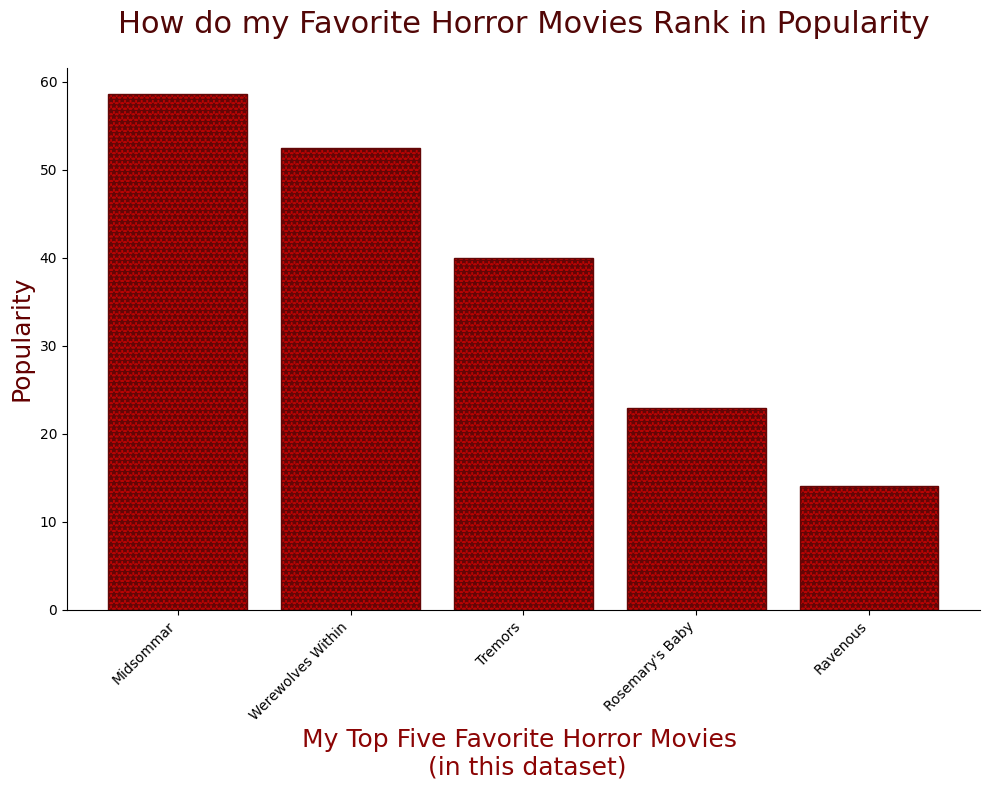

In [4]:
top_5_pop = my_top_5.groupby("title")["popularity"].sum().sort_values(ascending=False)


plt.figure(figsize=(10,8))
plt.bar(top_5_pop.index, top_5_pop.values, color=  "#b80404", edgecolor= "#630606",  hatch= "***")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xlabel("My Top Five Favorite Horror Movies \n (in this dataset)", fontsize= 18, color=  "#8B0404")
plt.ylabel("Popularity", fontsize= 18, color=  "#630000")
plt.title("How do my Favorite Horror Movies Rank in Popularity", fontsize= 22, color=  "#520707", pad=25)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig('../firstlook_visuals/mytop5pop.png')
plt.show()



from TMDB:
'Popularity is a fairly important metric here on TMDB. It helps us boost search results, adds an incredibly useful sort value for discover, and is also just kind of fun to see items chart up and down. You can think of popularity as being a "lifetime" popularity score that is impacted by the attributes below. It's calculated quite differently than trending.

Each model builds their popularity value slightly differently. Here are some of the attributes we use for each media type.

Movies
Number of votes for the day
Number of views for the day
Number of users who marked it as a "favourite" for the day
Number of users who added it to their "watchlist" for the day
Release date
Number of total votes
Previous days score'

This could explain why newer movies have higher popularity scores.
I would've assumed Rosemary's Baby would have the highest popularity score among my top faive favorite movies, but what if it's score is lower because it is actually so popular that people aren't looking it up or adding it to their watchlist? 
